# Step 1: Read File & Feature Preparation

Clustering khusus untuk **Non-Member (Guest)** menggunakan fitur transaksional (bukan RFM).

Dataset: `df_transaction_features.parquet` — filter `user_id.isna()`

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import joblib

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, QuantileTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from hdbscan import HDBSCAN

import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
gc.collect()
df_tx = pd.read_parquet('df_transaction_features.parquet')
gc.collect()

# Filter guest (non-member)
guest = df_tx[df_tx['user_id'].isna()].copy()
gc.collect()

print(f"Total guest transactions: {len(guest):,}")
print(f"Guest % dari total: {len(guest)/len(df_tx)*100:.1f}%")
print(f"Kolom guest: {len(guest.columns)} columns")

del df_tx
gc.collect()

Total guest transactions: 7,310,827
Guest % dari total: 50.0%
Kolom guest: 17 columns


0

In [3]:
guest.columns.tolist()

['transaction_id',
 'basket_size',
 'final_amount',
 'discount_applied',
 'is_weekend_bool',
 'is_voucher_used_bool',
 'hour',
 'month_name',
 'day_name',
 'city',
 'method_name',
 'payment_category',
 'member_status',
 'created_at',
 'user_id',
 'transaction_period',
 'item_count']

## Feature Engineering : Pembuatan Fitur Transaksional

In [4]:
# Hitung discount_ratio
guest['discount_ratio'] = guest['discount_applied'] / (guest['final_amount'] + guest['discount_applied'] + 1e-6)

# Feature columns untuk clustering (bukan RFM)
cluster_cols = [
    'final_amount',          # Monetary proxy: seberapa besar transaksi
    'basket_size',           # Berapa item yang dibeli
    'item_count',            # Variasi item unik
    'hour',                  # Jam belanja
    'is_weekend_bool',       # Weekend atau weekday
    'is_voucher_used_bool',  # Sensitivitas voucher
    'discount_ratio',        # Sensitivitas diskon
]

X = guest[cluster_cols].copy()
gc.collect()

print(f"Feature matrix shape: {X.shape}")
print(f"Feature columns: {cluster_cols}")
print()
print(X.head())

Feature matrix shape: (7310827, 7)
Feature columns: ['final_amount', 'basket_size', 'item_count', 'hour', 'is_weekend_bool', 'is_voucher_used_bool', 'discount_ratio']

   final_amount  basket_size  item_count  hour  is_weekend_bool  \
0          28.5            3           1     7                1   
1          33.0            4           2     7                1   
2          27.0            3           1     7                1   
3          45.5            6           3     7                1   
4          27.0            3           1     7                1   

   is_voucher_used_bool  discount_ratio  
0                     0             0.0  
1                     0             0.0  
2                     0             0.0  
3                     0             0.0  
4                     0             0.0  


## Statistik Deskriptif Fitur

In [5]:
print("Statistik deskriptif fitur clustering:")
print(X.describe().round(3))

Statistik deskriptif fitur clustering:
       final_amount  basket_size   item_count         hour  is_weekend_bool  \
count   7310827.000  7310827.000  7310827.000  7310827.000      7310827.000   
mean         30.935        3.748        1.839       12.076            0.288   
std          15.715        1.863        0.757        2.381            0.453   
min           0.000        1.000        1.000        7.000            0.000   
25%          18.000        2.000        1.000       10.000            0.000   
50%          28.500        3.000        2.000       12.000            0.000   
75%          42.000        5.000        2.000       14.000            1.000   
max          71.500        9.000        3.000       19.000            1.000   

       is_voucher_used_bool  discount_ratio  
count           7310827.000     7310827.000  
mean                  0.048           0.006  
std                   0.214           0.036  
min                   0.000           0.000  
25%                

# Step 2: Feature Transformations Pipeline

Menguji 7 metode scaling/transformasi untuk menentukan yang terbaik untuk K-Means.

In [6]:
# --- StandardScaler (ZScore) ---
scaler_z = StandardScaler()
ZScore = pd.DataFrame(
    scaler_z.fit_transform(X),
    columns=cluster_cols
)
gc.collect()

# --- Log1p ---
Log1p = np.log1p(X)
gc.collect()

# --- Log1p + ZScore ---
scaler_lz = StandardScaler()
LogZScore = pd.DataFrame(
    scaler_lz.fit_transform(Log1p),
    columns=cluster_cols
)
gc.collect()

# --- MinMaxScaler ---
scaler_mm = MinMaxScaler()
MinMax = pd.DataFrame(
    scaler_mm.fit_transform(X),
    columns=cluster_cols
)
gc.collect()

# --- Yeo-Johnson ---
scaler_yj = PowerTransformer(method='yeo-johnson', standardize=True)
YeoJohnson = pd.DataFrame(
    scaler_yj.fit_transform(X),
    columns=cluster_cols
)
gc.collect()

# --- QuantileTransformer ---
scaler_qt = QuantileTransformer(output_distribution='normal', random_state=42)
Quantile = pd.DataFrame(
    scaler_qt.fit_transform(X),
    columns=cluster_cols
)
gc.collect()

# --- Box-Cox (butuh semua nilai > 0) ---
# BoxCox hanya bisa untuk data positif. final_amount bisa 0, jadi +1 dulu
from sklearn.preprocessing import PowerTransformer
scaler_bc = PowerTransformer(method='box-cox', standardize=True)
X_boxcox = X + 1e-6  # hindari nol
BoxCox = pd.DataFrame(
    scaler_bc.fit_transform(X_boxcox),
    columns=cluster_cols
)
gc.collect()

print("All transformations complete:")
print(f"  ZScore:      {ZScore.shape}")
print(f"  Log1p:       {Log1p.shape}")
print(f"  Log+ZScore:  {LogZScore.shape}")
print(f"  MinMax:      {MinMax.shape}")
print(f"  YeoJohnson:  {YeoJohnson.shape}")
print(f"  Quantile:    {Quantile.shape}")
print(f"  BoxCox:      {BoxCox.shape}")

All transformations complete:
  ZScore:      (7310827, 7)
  Log1p:       (7310827, 7)
  Log+ZScore:  (7310827, 7)
  MinMax:      (7310827, 7)
  YeoJohnson:  (7310827, 7)
  Quantile:    (7310827, 7)
  BoxCox:      (7310827, 7)


# Step 3: Metric Evaluation (K-Means K=4)

Evaluasi semua transformasi dengan Silhouette Score & Davies-Bouldin Index.
Menggunakan **sample 1%** untuk efisiensi.

In [7]:
sample_fraction = 0.01
random_state = 42
gc.collect()

transform_dict = {
    'ZScore': ZScore,
    'Log1p': Log1p,
    'Log+ZScore': LogZScore,
    'MinMax': MinMax,
    'YeoJohnson': YeoJohnson,
    'Quantile': Quantile,
    'BoxCox': BoxCox
}
gc.collect()

# Sample each transformation
sampled = {}
for name, df_trans in transform_dict.items():
    sampled[name] = df_trans.sample(
        frac=sample_fraction,
        replace=False,
        random_state=random_state
    )
    print(f"Sampled {name}: {len(sampled[name]):,} rows")

gc.collect()
print(f"\nRandom sampling complete ({sample_fraction*100:.0f}% SRS WOR).")

Sampled ZScore: 73,108 rows
Sampled Log1p: 73,108 rows
Sampled Log+ZScore: 73,108 rows
Sampled MinMax: 73,108 rows
Sampled YeoJohnson: 73,108 rows
Sampled Quantile: 73,108 rows
Sampled BoxCox: 73,108 rows

Random sampling complete (1% SRS WOR).


In [8]:
# Evaluasi K-Means K=4 pada setiap transformasi
results = []
for name, df_sampled in sampled.items():
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_sampled)
    sil = silhouette_score(df_sampled, labels)
    dbi = davies_bouldin_score(df_sampled, labels)
    results.append({'Transform': name, 'Silhouette': sil, 'DBI': dbi})
    print(f"{name:12s} -> Silhouette={sil:.4f}, DBI={dbi:.4f}")

df_results = pd.DataFrame(results)
gc.collect()
print()
print("Best transform by Silhouette:", df_results.loc[df_results['Silhouette'].idxmax(), 'Transform'])
print("Best transform by DBI:       ", df_results.loc[df_results['DBI'].idxmin(), 'Transform'])

ZScore       -> Silhouette=0.3317, DBI=1.0456
Log1p        -> Silhouette=0.3599, DBI=1.0141
Log+ZScore   -> Silhouette=0.3511, DBI=1.0342
MinMax       -> Silhouette=0.4342, DBI=0.8820
YeoJohnson   -> Silhouette=0.3530, DBI=0.9977
Quantile     -> Silhouette=0.5510, DBI=0.7159
BoxCox       -> Silhouette=0.3554, DBI=0.9923

Best transform by Silhouette: Quantile
Best transform by DBI:        Quantile


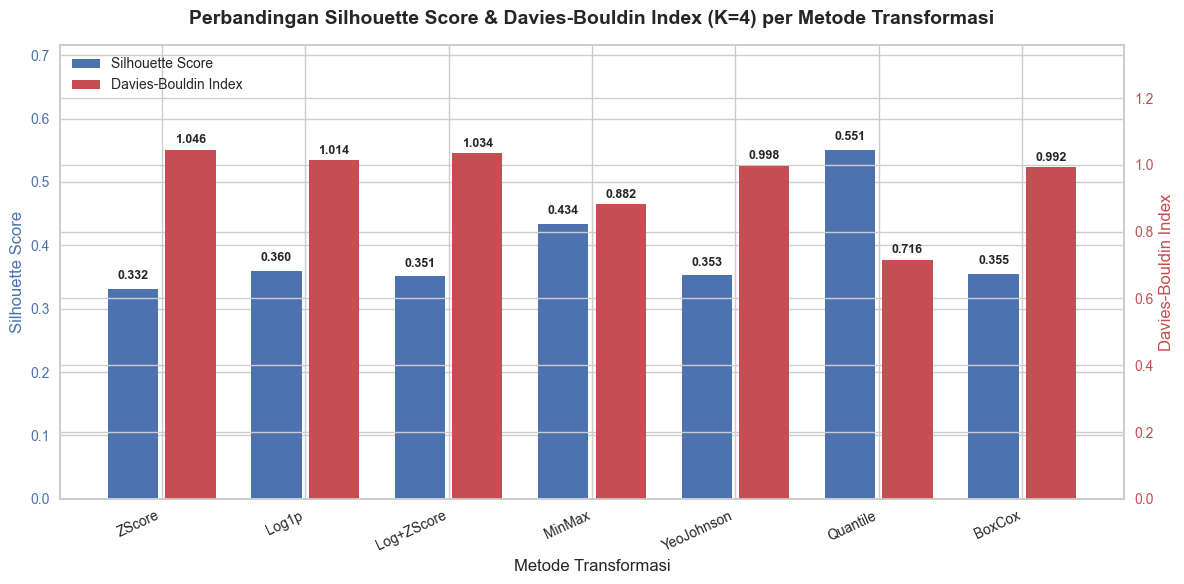


Best transform by Silhouette: Quantile


In [9]:
# Visualisasi perbandingan transformasi
fig, ax1 = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(df_results))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD', '#E5825C']

bars1 = ax1.bar(x_pos - 0.2, df_results['Silhouette'], width=0.35, color='#4C72B0', label='Silhouette Score')
ax1.set_ylabel('Silhouette Score', color='#4C72B0', fontsize=12)
ax1.set_ylim(0, max(df_results['Silhouette']) * 1.3)
ax1.tick_params(axis='y', labelcolor='#4C72B0')

ax2 = ax1.twinx()
bars2 = ax2.bar(x_pos + 0.2, df_results['DBI'], width=0.35, color='#C44E52', label='Davies-Bouldin Index')
ax2.set_ylabel('Davies-Bouldin Index', color='#C44E52', fontsize=12)
ax2.set_ylim(0, max(df_results['DBI']) * 1.3)
ax2.tick_params(axis='y', labelcolor='#C44E52')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_results['Transform'], rotation=25, ha='right', fontsize=10)
ax1.set_xlabel('Metode Transformasi', fontsize=12)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Perbandingan Silhouette Score & Davies-Bouldin Index (K=4) per Metode Transformasi',
          fontsize=14, fontweight='bold', pad=15)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='Silhouette Score'),
                   Patch(facecolor='#C44E52', label='Davies-Bouldin Index')]
ax1.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

best_transform_name = df_results.loc[df_results['Silhouette'].idxmax(), 'Transform']
print(f"\nBest transform by Silhouette: {best_transform_name}")

## Multi-K Silhouette/DBI pada Transformasi Terbaik

Menentukan jumlah cluster (K) optimal.

K=2: Silhouette=0.5015, DBI=0.8952
K=3: Silhouette=0.5071, DBI=0.7730
K=4: Silhouette=0.5510, DBI=0.7159
K=5: Silhouette=0.5759, DBI=0.6749
K=6: Silhouette=0.6002, DBI=0.6260
K=7: Silhouette=0.6428, DBI=0.5963
K=8: Silhouette=0.6525, DBI=0.5995
K=9: Silhouette=0.6646, DBI=0.5749
K=10: Silhouette=0.6816, DBI=0.5323

 k  Silhouette Score  Davies-Bouldin Index
 2          0.501527              0.895197
 3          0.507135              0.772997
 4          0.551005              0.715857
 5          0.575893              0.674948
 6          0.600217              0.626047
 7          0.642765              0.596269
 8          0.652456              0.599489
 9          0.664561              0.574902
10          0.681621              0.532296


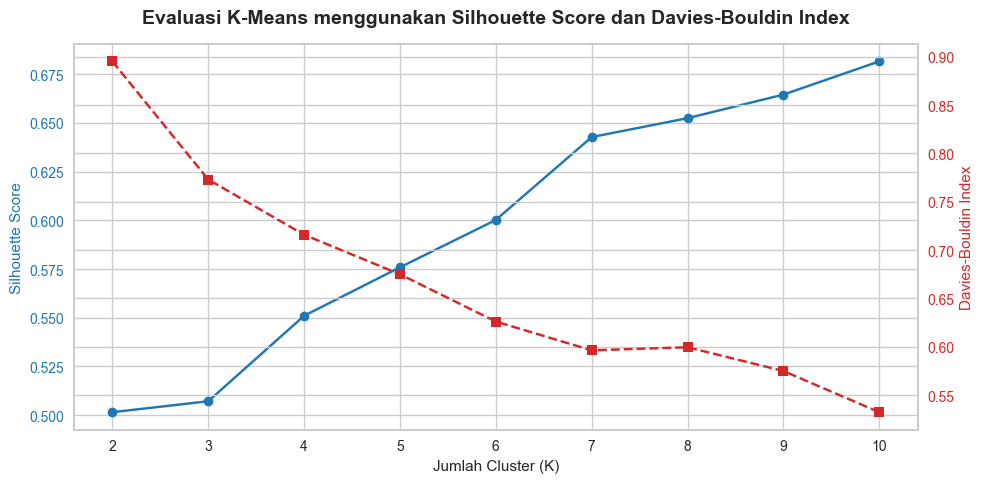


K terbaik berdasarkan Silhouette: K=10
K terbaik berdasarkan DBI:        K=10


In [10]:
best_df_sampled = sampled[best_transform_name]

silhouette_scores = []
dbi_scores = []
K_eval_range = range(2, 11)

for k in K_eval_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(best_df_sampled)
    sil = silhouette_score(best_df_sampled, labels)
    dbi = davies_bouldin_score(best_df_sampled, labels)
    silhouette_scores.append(sil)
    dbi_scores.append(dbi)
    print(f"K={k}: Silhouette={sil:.4f}, DBI={dbi:.4f}")

df_metrics = pd.DataFrame({
    'k': list(K_eval_range),
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Index': dbi_scores
})
print()
print(df_metrics.to_string(index=False))

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(K_eval_range, silhouette_scores, marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Index', color=color)
ax2.plot(K_eval_range, dbi_scores, marker='s', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi K-Means menggunakan Silhouette Score dan Davies-Bouldin Index',
          fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# Rekomendasi K
best_k_by_sil = df_metrics.loc[df_metrics['Silhouette Score'].idxmax(), 'k']
best_k_by_dbi = df_metrics.loc[df_metrics['Davies-Bouldin Index'].idxmin(), 'k']
print(f"\nK terbaik berdasarkan Silhouette: K={best_k_by_sil}")
print(f"K terbaik berdasarkan DBI:        K={best_k_by_dbi}")

# Step 4: Final Model — Mini-Batch KMeans pada FULL Data

Menggunakan **Mini-Batch KMeans** agar bisa memproses **7.3 juta baris** dengan cepat.
Transformasi terbaik diterapkan ke seluruh data.

In [11]:
optimal_k = 4

# Scale SEMUA data (bukan hanya sample) dengan transformasi terbaik
if best_transform_name == 'ZScore':
    scaler_final = StandardScaler()
    X_final = scaler_final.fit_transform(X)
elif best_transform_name == 'Log1p':
    X_final = np.log1p(X)
    scaler_final = None
elif best_transform_name == 'Log+ZScore':
    X_log = np.log1p(X)
    scaler_final = StandardScaler()
    X_final = scaler_final.fit_transform(X_log)
elif best_transform_name == 'MinMax':
    scaler_final = MinMaxScaler()
    X_final = scaler_final.fit_transform(X)
elif best_transform_name == 'YeoJohnson':
    scaler_final = PowerTransformer(method='yeo-johnson', standardize=True)
    X_final = scaler_final.fit_transform(X)
elif best_transform_name == 'Quantile':
    scaler_final = QuantileTransformer(output_distribution='normal', random_state=42)
    X_final = scaler_final.fit_transform(X)
elif best_transform_name == 'BoxCox':
    scaler_final = PowerTransformer(method='box-cox', standardize=True)
    X_final = scaler_final.fit_transform(X + 1e-6)

gc.collect()
print(f"Transformed data shape: {X_final.shape}")
print(f"Best transform used: {best_transform_name}")

Transformed data shape: (7310827, 7)
Best transform used: Quantile


In [12]:
# Train Mini-Batch KMeans pada FULL data 7.3M baris
print(f"Training Mini-Batch KMeans K={optimal_k} pada {len(X_final):,} baris...")

kmeans_guest = MiniBatchKMeans(
    n_clusters=optimal_k,
    random_state=42,
    batch_size=2048,
    n_init=5,
    max_iter=100
)

kmeans_guest.fit(X_final)
gc.collect()

# Predict untuk SEMUA baris
guest['cluster'] = kmeans_guest.predict(X_final)
gc.collect()

print(f"[OK] Selesai! Semua {len(guest):,} guest transaksi sudah punya cluster.")
print(f"\nDistribusi cluster:")
print(guest['cluster'].value_counts().sort_index())

Training Mini-Batch KMeans K=4 pada 7,310,827 baris...
[OK] Selesai! Semua 7,310,827 guest transaksi sudah punya cluster.

Distribusi cluster:
cluster
0    1894113
1    3089159
2    1976648
3     350907
Name: count, dtype: int64


In [13]:
# Evaluasi Silhouette pada sample
sample_idx = np.random.choice(len(X_final), size=min(50000, len(X_final)), replace=False)
final_sil = silhouette_score(X_final[sample_idx], guest['cluster'].iloc[sample_idx])
print(f"Silhouette Score (sample 50k): {final_sil:.4f}")

Silhouette Score (sample 50k): 0.5500


## Visualisasi 3D Cluster & Centroid

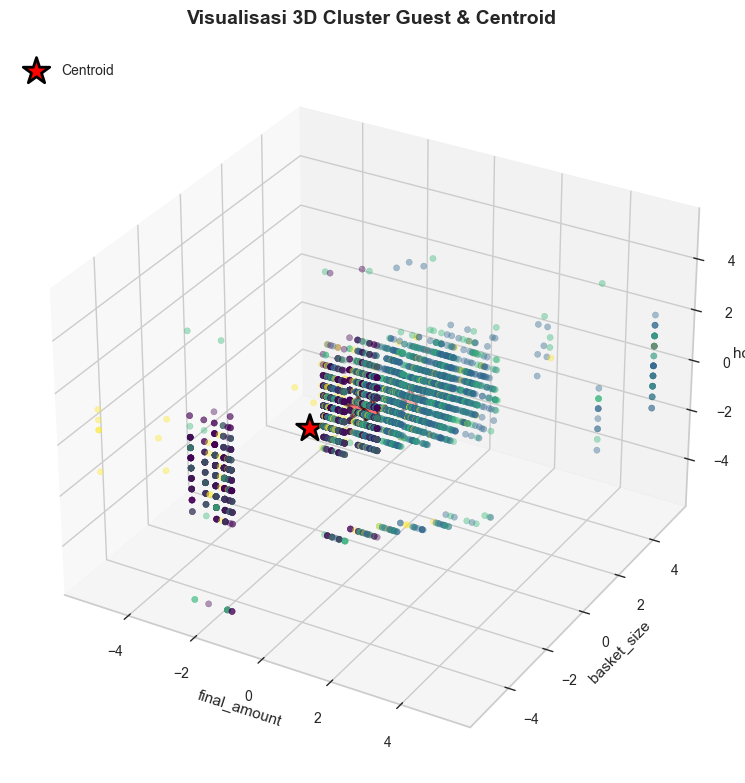

In [14]:
# Sample untuk visualisasi (biar tidak overload)
viz_sample_idx = np.random.choice(len(guest), size=5000, replace=False)
guest_viz = guest.iloc[viz_sample_idx]
X_viz = X_final[viz_sample_idx]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Pilih 3 fitur untuk sumbu
feature_indices = [0, 1, 3]  # final_amount, basket_size, hour
x_vals = X_viz[:, feature_indices[0]]
y_vals = X_viz[:, feature_indices[1]]
z_vals = X_viz[:, feature_indices[2]]

scatter = ax.scatter(x_vals, y_vals, z_vals,
    c=guest_viz['cluster'], cmap='viridis', s=20, alpha=0.4)

centroids = kmeans_guest.cluster_centers_[:, feature_indices]
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
    marker='*', s=400, c='red', edgecolor='black', linewidth=2, label='Centroid')

ax.set_xlabel(cluster_cols[feature_indices[0]])
ax.set_ylabel(cluster_cols[feature_indices[1]])
ax.set_zlabel(cluster_cols[feature_indices[2]])
plt.title('Visualisasi 3D Cluster Guest & Centroid', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## PCA 2D Visualization

In [15]:
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_viz)

centroids_2d = pca.transform(kmeans_guest.cluster_centers_)

explained_variance = pca.explained_variance_ratio_ * 100
print(f"Informasi PC1: {explained_variance[0]:.2f}%")
print(f"Informasi PC2: {explained_variance[1]:.2f}%")
print(f"Total informasi 7D yang terangkum di 2D: {sum(explained_variance):.2f}%")

Informasi PC1: 43.12%
Informasi PC2: 35.36%
Total informasi 7D yang terangkum di 2D: 78.48%


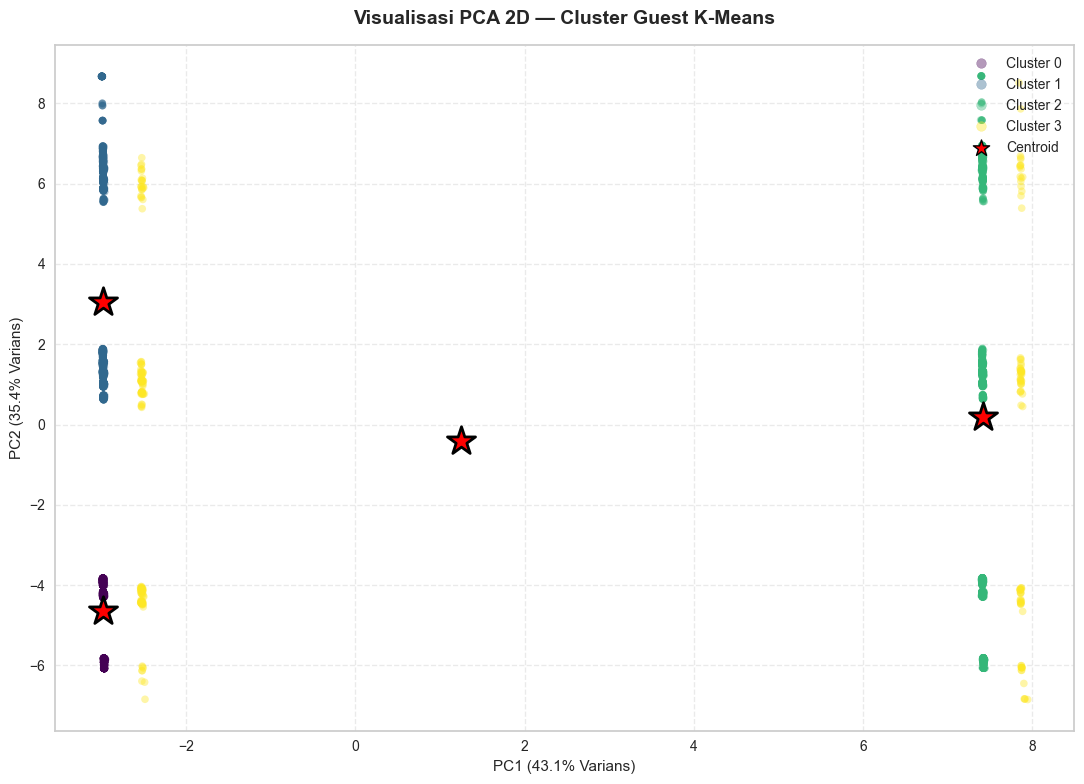

In [16]:
fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(pca_data[:, 0], pca_data[:, 1],
    c=guest_viz['cluster'], cmap='viridis', s=30, alpha=0.4, edgecolors='none')

ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
    marker='*', s=450, c='red', edgecolor='black', linewidth=2, label='Centroid')

ax.set_xlabel(f'PC1 ({explained_variance[0]:.1f}% Varians)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1f}% Varians)', fontsize=11)
plt.title('Visualisasi PCA 2D — Cluster Guest K-Means', fontsize=14, fontweight='bold', pad=15)

handles, _ = scatter.legend_elements(prop="colors")
legend_labels = [f'Cluster {i}' for i in range(optimal_k)] + ['Centroid']
centroid_handle = ax.scatter([], [], marker='*', s=150, c='red', edgecolor='black', linewidth=1)
ax.legend(handles + [centroid_handle], legend_labels, loc='upper right')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## HDBSCAN Clustering (Alternatif)

In [17]:
clusterer = HDBSCAN(
    min_cluster_size=500,
    min_samples=30,
    metric='euclidean',
    core_dist_n_jobs=-1,
    prediction_data=True
)

hdb_labels = clusterer.fit_predict(X_viz)
n_clusters_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = list(hdb_labels).count(-1)
print(f"HDBSCAN clusters found: {n_clusters_hdb}")
print(f"Noise points: {n_noise} ({n_noise/len(hdb_labels)*100:.1f}%)")

HDBSCAN clusters found: 5
Noise points: 232 (4.6%)


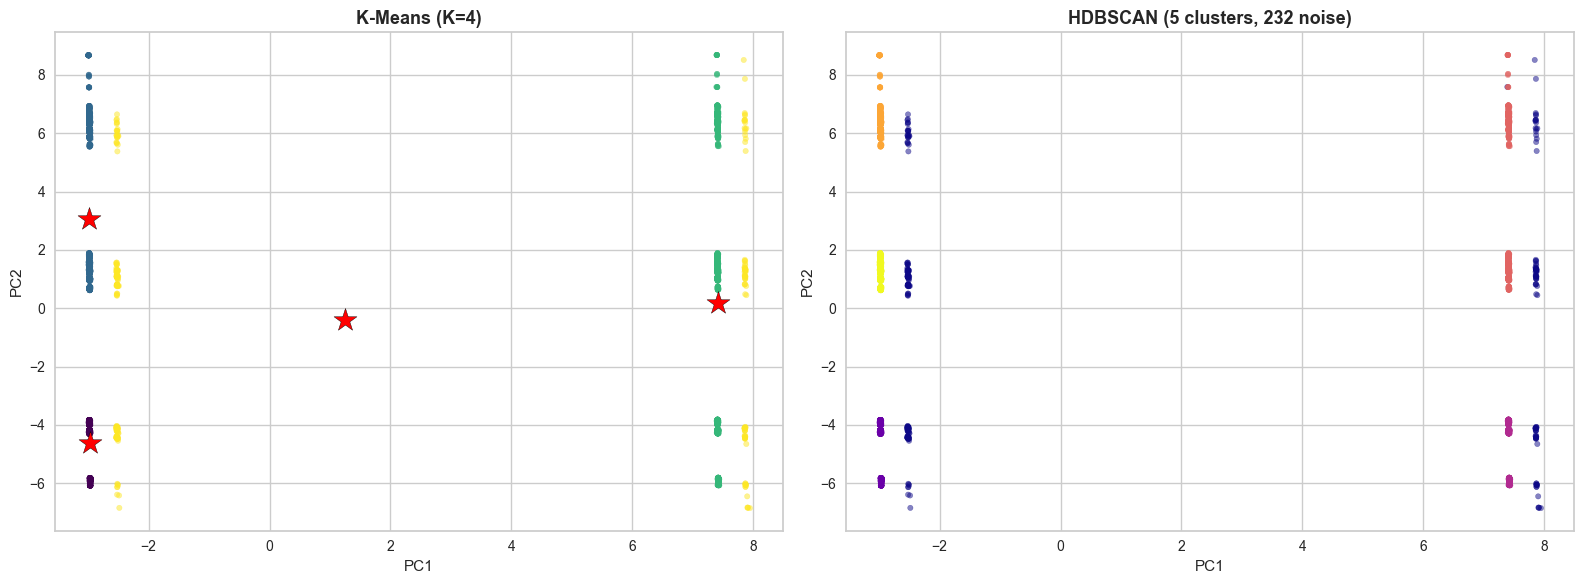

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
ax1.scatter(pca_data[:, 0], pca_data[:, 1], c=guest_viz['cluster'], cmap='viridis', s=15, alpha=0.5)
ax1.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker='*', s=300, c='red', edgecolor='black')
ax1.set_title(f'K-Means (K={optimal_k})', fontsize=13, fontweight='bold')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')

# HDBSCAN
scatter2 = ax2.scatter(pca_data[:, 0], pca_data[:, 1], c=hdb_labels, cmap='plasma', s=15, alpha=0.5)
ax2.set_title(f'HDBSCAN ({n_clusters_hdb} clusters, {n_noise} noise)', fontsize=13, fontweight='bold')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

plt.tight_layout()
plt.show()

# Step 5: Profiling Segmen & Save Model

Melihat karakteristik setiap cluster guest dan memberi label. Menyimpan model untuk digunakan di app.

In [19]:
cluster_profile = guest.groupby('cluster').agg(
    count=('transaction_id', 'count'),
    total_revenue=('final_amount', 'sum'),
    avg_amount=('final_amount', 'mean'),
    avg_basket=('basket_size', 'mean'),
    avg_items=('item_count', 'mean'),
    avg_hour=('hour', 'mean'),
    weekend_pct=('is_weekend_bool', 'mean'),
    voucher_pct=('is_voucher_used_bool', 'mean'),
    avg_discount=('discount_ratio', 'mean'),
).reset_index()

cluster_profile['pct'] = (cluster_profile['count'] / cluster_profile['count'].sum() * 100).round(1)
cluster_profile['revenue_pct'] = (cluster_profile['total_revenue'] / cluster_profile['total_revenue'].sum() * 100).round(1)
cluster_profile = cluster_profile.sort_values('avg_amount', ascending=False).reset_index(drop=True)
cluster_profile['Cluster_Number'] = range(optimal_k)

print("=== GUEST CLUSTER PROFILE ===")
print(cluster_profile.to_string(index=False))

=== GUEST CLUSTER PROFILE ===
 cluster   count  total_revenue  avg_amount  avg_basket  avg_items  avg_hour  weekend_pct  voucher_pct  avg_discount  pct  revenue_pct  Cluster_Number
       1 3089159   1.226094e+08   39.690205    4.783651   2.352597 12.077171     0.000000          0.0      0.000000 42.3         54.2               0
       2 1976648   6.149719e+07   31.111857    3.748608   1.838973 12.076431     1.000000          0.0      0.000000 27.0         27.2               1
       3  350907   9.664757e+06   27.542217    3.745779   1.837778 12.076123     0.361361          1.0      0.125835  4.8          4.3               2
       0 1894113   3.238878e+07   17.099706    2.057488   1.000000 12.073882     0.000000          0.0      0.000000 25.9         14.3               3


In [20]:
# Label segments with unique names based on profile
cluster_labels = {}
for _, row in cluster_profile.iterrows():
    cl = int(row['Cluster_Number'])
    amount = row['avg_amount']
    basket = row['avg_basket']
    voucher = row['voucher_pct']
    weekend = row['weekend_pct']
    hour = row['avg_hour']
    
    if amount > cluster_profile['avg_amount'].quantile(0.75):
        name = 'Big Spender'
    elif voucher >= 0.20:
        name = 'Deal Hunter'
    elif basket <= 2.5 and amount < cluster_profile['avg_amount'].median():
        name = 'Quick Buy'
    elif weekend >= 0.80:
        name = 'Weekend Visitor'
    else:
        name = 'Casual Guest'
    
    # Ensure unique names
    if name in cluster_labels.values():
        count = sum(1 for v in cluster_labels.values() if v.startswith(name))
        name = f'{name} #{count}'
    
    cluster_labels[cl] = name

cluster_profile['segment_name'] = cluster_profile['Cluster_Number'].map(cluster_labels)

# Mapping cluster_id (dari KMeans) -> segment_name
old_to_new = dict(zip(cluster_profile['cluster'], cluster_profile['Cluster_Number']))
cluster_id_to_name = dict(zip(cluster_profile['Cluster_Number'], cluster_profile['segment_name']))

print("=== NAMED SEGMENTS ===")
for _, row in cluster_profile.iterrows():
    print(f"  Cluster {int(row['Cluster_Number'])}: {row['segment_name']} ({row['pct']:.1f}%, Revenue: {row['revenue_pct']:.1f}%)")

=== NAMED SEGMENTS ===
  Cluster 0: Big Spender (42.3%, Revenue: 54.2%)
  Cluster 1: Weekend Visitor (27.0%, Revenue: 27.2%)
  Cluster 2: Deal Hunter (4.8%, Revenue: 4.3%)
  Cluster 3: Quick Buy (25.9%, Revenue: 14.3%)


In [21]:
# Apply segment names to all guest data
# Normalize cluster IDs so they are 0..K-1 consistently
cluster_mapping = dict(zip(cluster_profile['cluster'], cluster_profile['Cluster_Number']))
guest['cluster_normalized'] = guest['cluster'].map(cluster_mapping)
guest['segment_name'] = guest['cluster_normalized'].map(cluster_id_to_name)

print("=== DISTRIBUSI SEGMEN (FULL DATA) ===")
print(guest['segment_name'].value_counts())

=== DISTRIBUSI SEGMEN (FULL DATA) ===
segment_name
Big Spender        3089159
Weekend Visitor    1976648
Quick Buy          1894113
Deal Hunter         350907
Name: count, dtype: int64


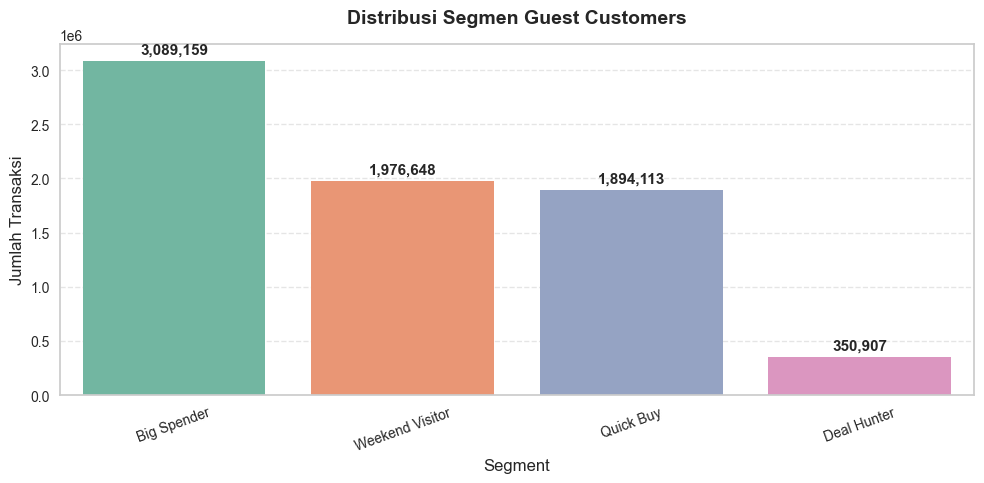

In [22]:
# Visualisasi distribusi segmen
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=guest['segment_name'].value_counts().index,
    y=guest['segment_name'].value_counts().values,
    palette='Set2',
    hue=guest['segment_name'].value_counts().index,
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='baseline', fontsize=11, fontweight='bold',
        xytext=(0, 5), textcoords='offset points')

plt.title('Distribusi Segmen Guest Customers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Jumlah Transaksi', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [23]:
# Detail profiling per segment
detail_cols = ['segment_name', 'count', 'pct', 'total_revenue', 'revenue_pct',
               'avg_amount', 'avg_basket', 'avg_items', 'avg_hour',
               'weekend_pct', 'voucher_pct', 'avg_discount']

detail_profile = cluster_profile[detail_cols].sort_values('count', ascending=False)
detail_profile.columns = ['Segment', 'Transactions', 'Tx_%', 'Revenue(RM)', 'Rev_%',
                          'Avg_Amount', 'Avg_Basket', 'Avg_Items', 'Avg_Hour',
                          'Weekend_%', 'Voucher_%', 'Avg_Discount']

print("\n=== DETAIL SEGMENT PROFILE ===")
print(detail_profile.to_string(index=False))


=== DETAIL SEGMENT PROFILE ===
        Segment  Transactions  Tx_%  Revenue(RM)  Rev_%  Avg_Amount  Avg_Basket  Avg_Items  Avg_Hour  Weekend_%  Voucher_%  Avg_Discount
    Big Spender       3089159  42.3 1.226094e+08   54.2   39.690205    4.783651   2.352597 12.077171   0.000000        0.0      0.000000
Weekend Visitor       1976648  27.0 6.149719e+07   27.2   31.111857    3.748608   1.838973 12.076431   1.000000        0.0      0.000000
      Quick Buy       1894113  25.9 3.238878e+07   14.3   17.099706    2.057488   1.000000 12.073882   0.000000        0.0      0.000000
    Deal Hunter        350907   4.8 9.664757e+06    4.3   27.542217    3.745779   1.837778 12.076123   0.361361        1.0      0.125835


In [24]:
detail_profile

,Segment,Transactions,Tx_%,Revenue(RM),Rev_%,Avg_Amount,Avg_Basket,Avg_Items,Avg_Hour,Weekend_%,Voucher_%,Avg_Discount
0,Big Spender,3089159,42.3,1.226094e+08,54.2,39.690205,4.783651,2.352597,12.077171,0.000000,0.0,0.000000
1,Weekend Visitor,1976648,27.0,6.149719e+07,27.2,31.111857,3.748608,1.838973,12.076431,1.000000,0.0,0.000000
3,Quick Buy,1894113,25.9,3.238878e+07,14.3,17.099706,2.057488,1.000000,12.073882,0.000000,0.0,0.000000
2,Deal Hunter,350907,4.8,9.664757e+06,4.3,27.542217,3.745779,1.837778,12.076123,0.361361,1.0,0.125835


## Save Model & Data

In [25]:
gc.collect()

# Save KMeans model
joblib.dump(kmeans_guest, 'model_kmeans_guest.joblib')
print("[OK] Saved: model_kmeans_guest.joblib")

# Save scaler (if exists)
if scaler_final is not None:
    joblib.dump(scaler_final, 'scaler_guest.joblib')
    print("[OK] Saved: scaler_guest.joblib")

# Save metadata untuk mapping cluster di app
import json
metadata = {
    'best_transform': best_transform_name,
    'cluster_cols': cluster_cols,
    'optimal_k': optimal_k,
    'cluster_id_to_name': {str(k): v for k, v in cluster_id_to_name.items()},
    'model_type': 'MiniBatchKMeans'
}
with open('guest_cluster_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("[OK] Saved: guest_cluster_metadata.json")

# Save guest data with segment
guest.to_parquet('df_guest_with_segments.parquet', index=False)
print("[OK] Saved: df_guest_with_segments.parquet (dengan cluster + segment_name)")

gc.collect()

[OK] Saved: model_kmeans_guest.joblib
[OK] Saved: scaler_guest.joblib
[OK] Saved: guest_cluster_metadata.json
[OK] Saved: df_guest_with_segments.parquet (dengan cluster + segment_name)


0

In [26]:
gc.collect()
print('=== K-Means Non-Member Clustering Complete ===')
print(f'Total guest transaksi: {len(guest):,}')
print(f'Jumlah cluster: {optimal_k}')
print(f'Silhouette Score: {final_sil:.4f}')
print(f'Transformasi terbaik: {best_transform_name}')

=== K-Means Non-Member Clustering Complete ===
Total guest transaksi: 7,310,827
Jumlah cluster: 4
Silhouette Score: 0.5500
Transformasi terbaik: Quantile
